In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("D:\\datasets\\insurance_cleaned.csv")

In [5]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
8,37,male,29.83,2,no,northeast,6406.41070
632,20,male,40.47,0,no,northeast,1984.45330
941,45,female,31.79,0,no,southeast,17929.30337
298,49,female,41.47,4,no,southeast,10977.20630
502,18,female,32.12,2,no,southeast,2801.25880


In [10]:
# Dataset info
print(df.info())

# Shape
print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1190 non-null   int64  
 1   sex       1190 non-null   object 
 2   bmi       1190 non-null   float64
 3   children  1190 non-null   int64  
 4   smoker    1190 non-null   object 
 5   region    1190 non-null   object 
 6   charges   1190 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 65.2+ KB
None
Shape: (1190, 7)


In [11]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [12]:
categorical_features = ["sex", "smoker", "region"]
numerical_features = ["age", "bmi", "children"]

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(drop='first'),
            categorical_features
        )
    ]
)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

# Predictions
linear_pred = linear_pipeline.predict(X_test)

In [16]:
print("LINEAR REGRESSION RESULTS")
print("R2 Score:", r2_score(y_test, linear_pred))
print("MAE:", mean_absolute_error(y_test, linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, linear_pred)))

LINEAR REGRESSION RESULTS
R2 Score: 0.5342035273396168
MAE: 2669.1228446526748
RMSE: 4738.387119547359


In [17]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            random_state=42
        )
    )
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

In [18]:
print("RANDOM FOREST RESULTS")
print("R2 Score:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

RANDOM FOREST RESULTS
R2 Score: 0.4832984916866009
MAE: 2672.8818053151176
RMSE: 4990.594757227763


In [22]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)


In [23]:
print("XGBOOST RESULTS")
print("R2 Score:", r2_score(y_test, xgb_pred))
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

XGBOOST RESULTS
R2 Score: 0.5107486039564517
MAE: 2705.224280508726
RMSE: 4856.221396761574


In [24]:
import joblib

joblib.dump(xgb_pipeline, "insurance_model.pkl")

print("Model saved successfully")

Model saved successfully


In [25]:
model = xgb_pipeline.named_steps['model']

print(model.feature_importances_)

[0.0842113  0.03580616 0.03138816 0.0254857  0.75000775 0.02895886
 0.0234951  0.02064694]


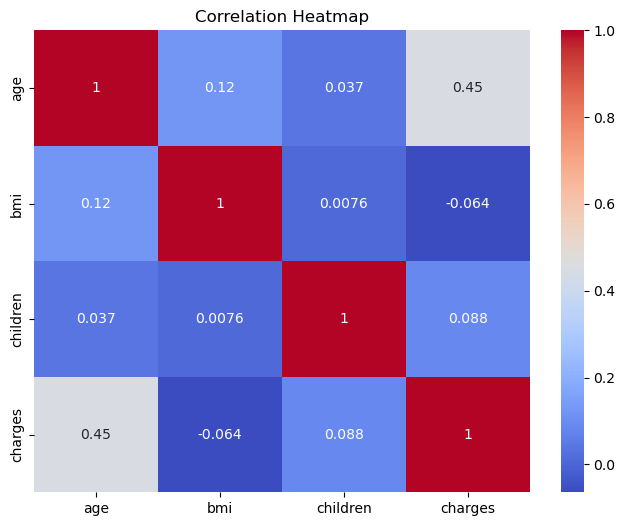

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

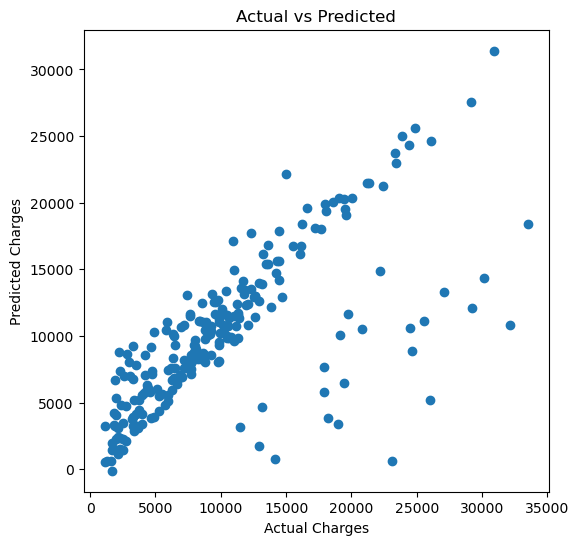

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, xgb_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()